# Stochastic Brock-Mirman — framework walkthrough

> Simon's Geneva Day 2 notebook (`02_Brock_Mirman_Uncertainty_DEQN.ipynb`) *builds* DEQN from scratch in TensorFlow: it hand-writes the network, the Gauss-Hermite quadrature, the loss, the training loop, and the diagnostic plots in a single file. That is the pedagogical view.
>
> **This notebook is the production view.** The same economic model is trained through the framework: one `train_from_config` call, a declarative `ModelSpec`, and a library of composable diagnostics. Nothing in this notebook is specific to Brock-Mirman except the model registration string and the plots that interpret the particular economics.

## Model

Representative agent maximizes
$$\max_{\{C_t\}} \mathbb{E}_0 \sum_t \beta^t \ln C_t \quad\text{s.t.}\quad K_{t+1} = (1-\delta)K_t + Z_t K_t^{\alpha} - C_t$$
with log utility ($\gamma = 1$), $\alpha = 0.36$, $\beta = 0.99$, $\delta = 0.1$, and AR(1) TFP in logs
$$z_{t+1} = \rho_z\, z_t + \sigma_z\, \varepsilon_{t+1}, \qquad \varepsilon \sim \mathcal{N}(0,1),$$
where $Z_t = \exp(z_t)$. Calibration mirrors Simon's notebook to make visual diffs trivial: $\rho_z = 0.9$, $\sigma_z = 0.04$.

## Euler FOC

The FOC for $s_t$ (savings rate) is
$$\frac{1}{C_t} = \beta\, \mathbb{E}_t\!\left[\frac{1 + r_{t+1} - \delta}{C_{t+1}}\right], \qquad r_{t+1} = \alpha Z_{t+1} K_{t+1}^{\alpha-1}.$$
The framework represents this as a **per-shock residual** that averages correctly under MC sampling (see [`equations.py`](../src/deqn_jax/models/brock_mirman/equations.py) for the dimensionless form and a note on why ratio forms break under stochastic expectation).

## What the framework provides

- **`ModelSpec`** — declarative model registration in `src/deqn_jax/models/brock_mirman/`.
- **`train_from_config(cfg)`** — single entry point; handles MC/quadrature expectation, rollouts, optimizer dispatch, logging.
- **`evaluate.euler_equation_errors`** — simulate ergodic path + report log₁₀|residual| distribution (Azinovic et al. 2022 gold standard).
- **`irf.run_irf`** — impulse response to any named shock.
- **`deqn_jax.plots.*`** — pure-function plots consuming `history` / `irf_results` dicts.

In [1]:
# Notebook setup: rich pytree / array displays.
# treescope (transitive dep of penzai, in dev deps) replaces the default
# repr for JAX arrays and registered pytrees with a collapsible widget
# showing shape, dtype, and stats. Useful for inspecting TrainState,
# the policy network, and residual arrays during a training run.
import treescope

treescope.basic_interactive_setup(autovisualize_arrays=True)

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import NetworkConfig, OptimizerConfig, TrainConfig
from deqn_jax.evaluate import euler_equation_errors
from deqn_jax.irf import run_irf
from deqn_jax.models.brock_mirman import MODEL
from deqn_jax.models.brock_mirman.dynamics import step as bm_step
from deqn_jax.models.brock_mirman.equations import (
    equations as bm_equations,
)
from deqn_jax.models.brock_mirman.steady_state import (
    K_LB,
    K_UB,
    Z_LB,
    Z_UB,
    steady_state,
)
from deqn_jax.plots import plot_irf_grid, plot_loss_curve
from deqn_jax.training.trainer import train_from_config

## 1. Inspect the model

The `ModelSpec` is the contract. Everything the trainer needs is declared here; we don't plumb pieces by hand.

In [3]:
print(f"name          : {MODEL.name}")
print(f"states        : {MODEL.state_names}")
print(f"policies      : {MODEL.policy_names}")
print(f"equations     : {MODEL.equation_names}")
print(f"shocks        : {MODEL.shock_names} ({MODEL.n_shocks} dim)")
print()
for k, v in MODEL.constants.items():
    print(f"  {k:8s} = {v}")

ss_state, ss_policy = steady_state(MODEL.constants)
print()
print("Deterministic steady state:")
print(f"  K_ss     = {float(ss_state[0]):.4f}")
print(f"  z_ss     = {float(ss_state[1]):.4f}   (Z_ss = 1.0)")
print(f"  s_ss     = {float(ss_policy[0]):.4f}")
print()
print(
    f"Training rect: k in [{K_LB}, {K_UB}], z in [{Z_LB:.3f}, {Z_UB:.3f}]  (Z in [0.70, 1.30])"
)

name          : brock_mirman
states        : ('k', 'z')
policies      : ('sav_rate',)
equations     : ('euler',)
shocks        : ('eps_z',) (1 dim)

  alpha    = 0.36
  beta     = 0.99
  gamma    = 1.0
  delta    = 0.1
  rho_z    = 0.9
  sigma_z  = 0.04

Deterministic steady state:
  K_ss     = 6.3668
  z_ss     = 0.0000   (Z_ss = 1.0)
  s_ss     = 0.3270

Training rect: k in [0.9, 12.0], z in [-0.357, 0.262]  (Z in [0.70, 1.30])


## 2. Train

Config mirrors the reference recipe:

| knob | value | why |
|---|---|---|
| `episode_length` | 1 | exogenous-rect sampling phase (no rollout) |
| `initialize_each_episode` | `True` | redraw uniformly from the rect each cycle |
| `mc_samples` | 5 | matches reference Gauss-Hermite $n_\text{int}=5$ |
| `optimizer.lr_schedule` | `cosine` | our single-phase equivalent of reference's manual 3e-4 → 1e-4 drop |
| `network` | 50-50 ReLU, Xavier | matches Keras' `Dense(relu) + glorot_uniform` |

For stochastic-rollout training, simulated-moment matching, or composite losses, the same entry point applies — you'd flip `initialize_each_episode=False`, raise `episode_length`, or set `loss_type='composite'`. None of that is turned on here.

In [4]:
cfg = TrainConfig(
    model="brock_mirman",
    episodes=20001,
    batch_size=128,
    episode_length=1,
    mc_samples=5,
    n_epochs_per_rollout=1,
    n_minibatches_per_epoch=1,
    initialize_each_episode=True,
    network=NetworkConfig(
        hidden_sizes=(50, 50), activation="relu", init="xavier_uniform"
    ),
    optimizer=OptimizerConfig(
        name="adam", learning_rate=3e-4, lr_schedule="cosine", lr_min_factor=0.1
    ),
    warm_start=False,
    seed=0,
    verbose=False,
)

policy_net, history = train_from_config(cfg)

print(f"Initial loss:  {history['loss'][0]:.3e}")
print(f"Final   loss:  {history['loss'][-1]:.3e}")

Initial loss:  1.536e+00
Final   loss:  7.843e-06


## 3. Loss curve

`plot_loss_curve` is a pure function of the returned `history` dict. Same call in any other model's notebook.

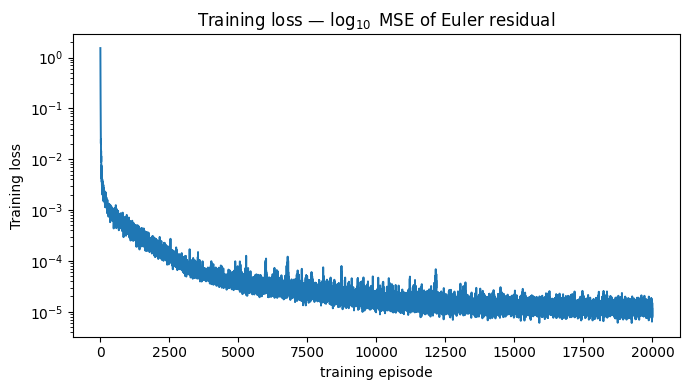

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_loss_curve(history, ax=ax, log_y=True)
ax.set_title("Training loss — $\\log_{10}$ MSE of Euler residual")
ax.set_xlabel("training episode")
plt.tight_layout()
plt.show()

## 4. Policy

Mirroring the reference (Geneva 2026 Day 2 Exercise 1), we scatter the trained
policy over a uniform batch drawn from the training rect, against each state.

- **Capital choice** $K_{t+1}$ vs $K_t$ (with the 45° line and the deterministic
  fixed point) and vs $Z$.
- **Consumption** $C_t$ vs $K_t$ and vs $Z$.
- **Savings rate** $s(K,Z)$ vs each state, drawn on a fixed $[0, 0.5]$ axis with
  the $\alpha\beta$ reference line. With $\delta = 0.1$ this model has **no
  closed-form policy**, so there is no analytic curve to overlay; the honest read
  is that $s$ sits in a narrow band near $\alpha\beta = 0.356$ and varies weakly —
  an autoscaled axis would magnify that band into spurious "structure".

In [ ]:
from deqn_jax.models.brock_mirman.equations import definitions as bm_defs

# Uniform batch over the training rect (reference samples the policy this way).
key = jax.random.PRNGKey(3)
k_key, z_key = jax.random.split(key)
n_pts = 2000
k_samp = jax.random.uniform(k_key, (n_pts,), minval=K_LB, maxval=K_UB)
z_samp = jax.random.uniform(z_key, (n_pts,), minval=Z_LB, maxval=Z_UB)
states_samp = jnp.stack([k_samp, z_samp], axis=1)

pol_samp = jax.vmap(policy_net)(states_samp)
defs_samp = bm_defs(states_samp, pol_samp, MODEL.constants)
zero_shock = jnp.zeros((n_pts, MODEL.n_shocks))
next_states = bm_step(states_samp, pol_samp, zero_shock, MODEL.constants)

K_s = np.asarray(k_samp)
Z_s = np.exp(np.asarray(z_samp))
K_next_s = np.asarray(next_states[:, 0])
C_s = np.asarray(defs_samp["c"])
s_s = np.asarray(pol_samp[:, 0])

K_ss = float(ss_state[0])
alpha_beta = MODEL.constants["alpha"] * MODEL.constants["beta"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Capital choice vs capital, with diagonal + deterministic fixed point.
axes[0, 0].scatter(K_s, K_next_s, s=8, alpha=0.4, color="C0", label="$K_{t+1}$")
diag = np.linspace(K_LB, K_UB, 2)
axes[0, 0].plot(diag, diag, color="grey", lw=1.5, label="$K_{t+1}=K_t$")
axes[0, 0].scatter([K_ss], [K_ss], color="k", marker="*", s=160, zorder=5,
                   label=f"det. SS ({K_ss:.2f})")
axes[0, 0].set_xlabel("capital $K_t$")
axes[0, 0].set_ylabel("next capital $K_{t+1}$")
axes[0, 0].set_title("capital policy vs capital")
axes[0, 0].legend(fontsize=8)

axes[0, 1].scatter(Z_s, K_next_s, s=8, alpha=0.4, color="C0")
axes[0, 1].set_xlabel("TFP $Z_t$")
axes[0, 1].set_ylabel("next capital $K_{t+1}$")
axes[0, 1].set_title("capital policy vs TFP")

# Savings rate vs capital, honest fixed range so the flat band reads as flat.
axes[0, 2].scatter(K_s, s_s, s=8, alpha=0.4, color="C1")
axes[0, 2].axhline(alpha_beta, color="k", ls="--", lw=1,
                   label=rf"$\alpha\beta = {alpha_beta:.3f}$")
axes[0, 2].set_ylim(0.0, 0.5)
axes[0, 2].set_xlabel("capital $K_t$")
axes[0, 2].set_ylabel("savings rate $s$")
axes[0, 2].set_title("savings policy vs capital")
axes[0, 2].legend(fontsize=8)

# Consumption vs capital and vs TFP.
axes[1, 0].scatter(K_s, C_s, s=8, alpha=0.4, color="C2")
axes[1, 0].set_xlabel("capital $K_t$")
axes[1, 0].set_ylabel("consumption $C_t$")
axes[1, 0].set_title("consumption policy")

axes[1, 1].scatter(Z_s, C_s, s=8, alpha=0.4, color="C2")
axes[1, 1].set_xlabel("TFP $Z_t$")
axes[1, 1].set_ylabel("consumption $C_t$")
axes[1, 1].set_title("consumption policy")

axes[1, 2].scatter(Z_s, s_s, s=8, alpha=0.4, color="C1")
axes[1, 2].axhline(alpha_beta, color="k", ls="--", lw=1,
                   label=rf"$\alpha\beta = {alpha_beta:.3f}$")
axes[1, 2].set_ylim(0.0, 0.5)
axes[1, 2].set_xlabel("TFP $Z_t$")
axes[1, 2].set_ylabel("savings rate $s$")
axes[1, 2].set_title("savings policy vs TFP")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"savings rate s: [{s_s.min():.4f}, {s_s.max():.4f}]  (alpha*beta = {alpha_beta:.4f})")

## 5. Capital transition

$K_{t+1}$ vs $K_t$ at three $Z$ slices (low/mid/high). Curves are monotone increasing, shift up with $Z$, and cross the 45° line at the $Z$-conditional attractor.

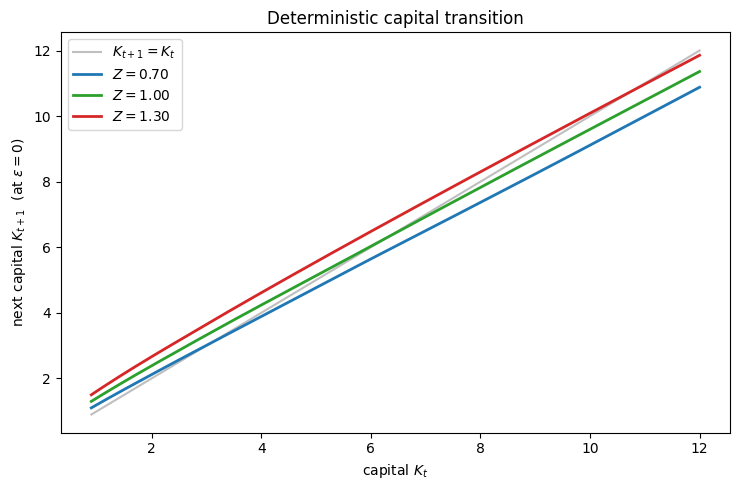

In [7]:
k_line = jnp.linspace(K_LB, K_UB, 200)
z_slices = [Z_LB, 0.0, Z_UB]
zero_shock_line = jnp.zeros((k_line.shape[0], MODEL.n_shocks))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(
    np.asarray(k_line), np.asarray(k_line), color="grey", alpha=0.5, lw=1.5,
    label="$K_{t+1}=K_t$",
)
colors = ["C0", "C2", "C3"]
for z_val, color in zip(z_slices, colors):
    states = jnp.stack([k_line, jnp.full_like(k_line, z_val)], axis=1)
    policies = jax.vmap(policy_net)(states)
    next_states = bm_step(states, policies, zero_shock_line, MODEL.constants)
    k_next = np.asarray(next_states[:, 0])
    ax.plot(
        np.asarray(k_line), k_next, color=color, lw=2,
        label=rf"$Z = {np.exp(z_val):.2f}$",
    )
ax.set_xlabel("capital $K_t$")
ax.set_ylabel(r"next capital $K_{t+1}$  (at $\varepsilon = 0$)")
ax.set_title("Deterministic capital transition")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Relative Euler error

The reference notebook's accuracy diagnostic is the **signed relative Euler
error**, computed with 5-node Gauss-Hermite quadrature over the TFP innovation
(Geneva 2026 Day 2 Exercise 1):

$$\mathrm{errREE} = 1 - \frac{1}{C_t\,\beta\,\mathbb{E}_t\!\left[\dfrac{1+r_{t+1}-\delta}{C_{t+1}}\right]},
\qquad \mathrm{LHS} = \frac{1}{C_t},\quad \mathrm{RHS} = \beta\,\mathbb{E}_t[\cdot].$$

We reproduce it verbatim with `deqn_jax` model quantities. It is plotted as a
**signed, linear** scatter against each state with a zero reference line — not
$\log_{10}|\text{residual}|$, which would spike to $-\infty$ at every sign change.
A well-trained policy sits in a thin band around zero (that small scale *is* the
result). The companion LHS-vs-RHS panels show the two sides of the Euler equation
overlapping.

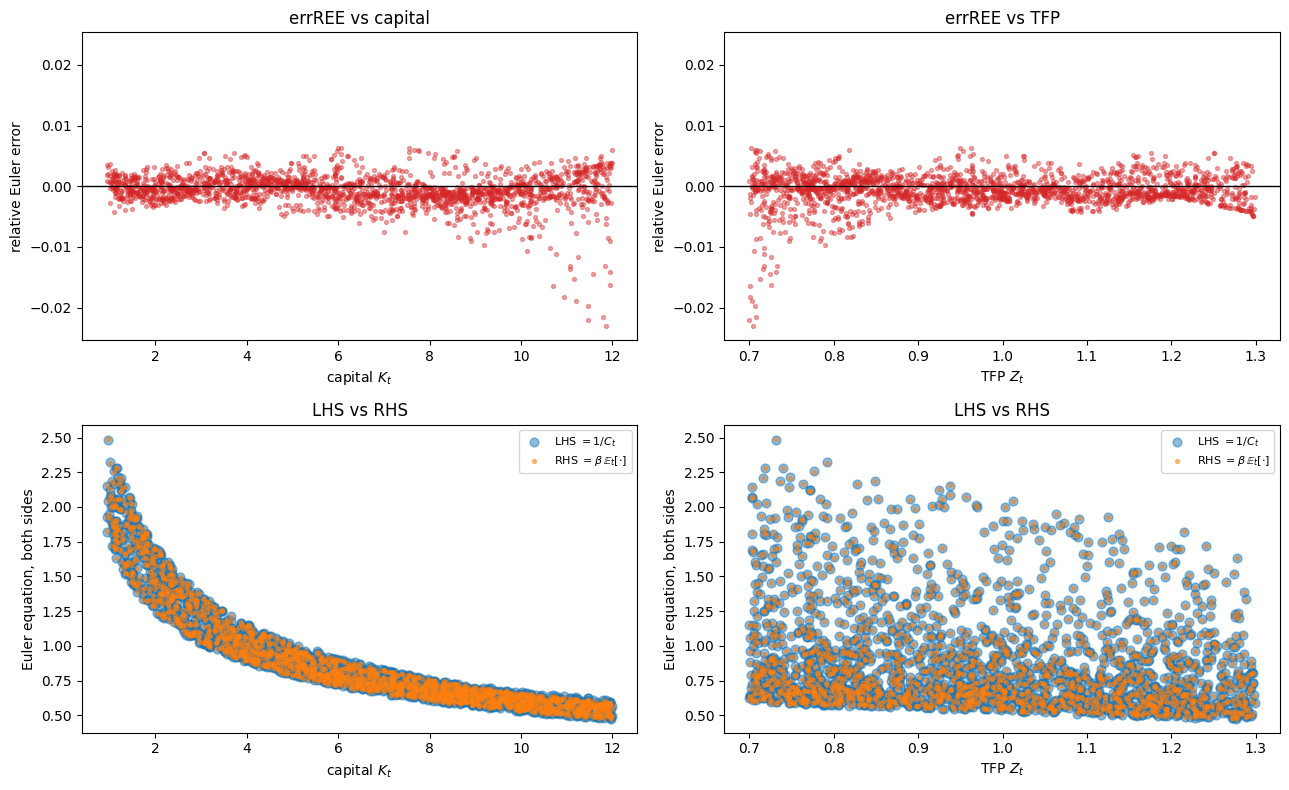

errREE  median |.| = 1.452e-03   max |.| = 2.305e-02


In [8]:
from deqn_jax.models.brock_mirman.equations import definitions as bm_defs

# Reference relative Euler error (Geneva 2026 Day 2 Exercise 1), reproduced with
# deqn_jax quantities and 5-node Gauss-Hermite quadrature over the TFP innovation:
#   errREE = 1 - 1 / ( C_t * beta * E_t[ (1 + r' - delta) / C' ] )
const = MODEL.constants
alpha, beta, delta = const["alpha"], const["beta"], const["delta"]
rho_z, sigma_z = const["rho_z"], const["sigma_z"]

n_int = 5  # matches the reference n_int = 5
gh_nodes, gh_w = np.polynomial.hermite.hermgauss(n_int)
gh_w = jnp.asarray(gh_w / np.sqrt(np.pi))        # probabilists' weights, sum to 1
gh_eps = jnp.asarray(gh_nodes * np.sqrt(2.0))    # standard-normal nodes


def rel_euler_error(states):
    """Signed errREE, LHS=1/C_t, RHS=beta*E[.], by Gauss-Hermite quadrature."""
    pol = jax.vmap(policy_net)(states)
    d = bm_defs(states, pol, MODEL.constants)
    c_t = d["c"]
    k_next = (1.0 - delta) * states[:, 0] + d["s"]
    z_t = states[:, 1]

    def inside(eps):
        z_next = rho_z * z_t + sigma_z * eps
        next_states = jnp.stack([k_next, z_next], axis=1)
        next_pol = jax.vmap(policy_net)(next_states)
        dn = bm_defs(next_states, next_pol, MODEL.constants)
        return (1.0 - delta + dn["mpk"]) / dn["c"]

    inside_all = jax.vmap(inside)(gh_eps)              # [n_int, N]
    expectation = jnp.einsum("i,ij->j", gh_w, inside_all)
    lhs = 1.0 / c_t
    rhs = beta * expectation
    err = 1.0 - 1.0 / (c_t * beta * expectation)
    return err, lhs, rhs


# Uniform batch over the training rect (same sampling style as the reference).
key = jax.random.PRNGKey(11)
k_key, z_key = jax.random.split(key)
n_pts = 2000
k_samp = jax.random.uniform(k_key, (n_pts,), minval=K_LB, maxval=K_UB)
z_samp = jax.random.uniform(z_key, (n_pts,), minval=Z_LB, maxval=Z_UB)
states_ree = jnp.stack([k_samp, z_samp], axis=1)

err, lhs, rhs = rel_euler_error(states_ree)
K_r = np.asarray(k_samp)
Z_r = np.exp(np.asarray(z_samp))
err = np.asarray(err)
lhs = np.asarray(lhs)
rhs = np.asarray(rhs)

# Honest symmetric range about zero: this small scale IS the result.
ree_lim = float(np.abs(err).max()) * 1.1

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].scatter(K_r, err, s=8, alpha=0.4, color="C3")
axes[0, 0].axhline(0.0, color="k", lw=1)
axes[0, 0].set_ylim(-ree_lim, ree_lim)
axes[0, 0].set_xlabel("capital $K_t$")
axes[0, 0].set_ylabel("relative Euler error")
axes[0, 0].set_title("errREE vs capital")

axes[0, 1].scatter(Z_r, err, s=8, alpha=0.4, color="C3")
axes[0, 1].axhline(0.0, color="k", lw=1)
axes[0, 1].set_ylim(-ree_lim, ree_lim)
axes[0, 1].set_xlabel("TFP $Z_t$")
axes[0, 1].set_ylabel("relative Euler error")
axes[0, 1].set_title("errREE vs TFP")

axes[1, 0].scatter(K_r, lhs, s=40, alpha=0.5, color="C0", label="LHS $= 1/C_t$")
axes[1, 0].scatter(K_r, rhs, s=8, alpha=0.5, color="C1",
                   label=r"RHS $= \beta\,\mathbb{E}_t[\cdot]$")
axes[1, 0].set_xlabel("capital $K_t$")
axes[1, 0].set_ylabel("Euler equation, both sides")
axes[1, 0].set_title("LHS vs RHS")
axes[1, 0].legend(fontsize=8)

axes[1, 1].scatter(Z_r, lhs, s=40, alpha=0.5, color="C0", label="LHS $= 1/C_t$")
axes[1, 1].scatter(Z_r, rhs, s=8, alpha=0.5, color="C1",
                   label=r"RHS $= \beta\,\mathbb{E}_t[\cdot]$")
axes[1, 1].set_xlabel("TFP $Z_t$")
axes[1, 1].set_ylabel("Euler equation, both sides")
axes[1, 1].set_title("LHS vs RHS")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"errREE  median |.| = {np.median(np.abs(err)):.3e}   max |.| = {np.abs(err).max():.3e}")

## 7. Ergodic simulation

Simulate 10,000 periods from the deterministic steady state. `euler_equation_errors`
returns the per-period residuals and the simulated state path. The first panel is the
reference's **ergodic cloud** — a $(Z, K)$ scatter; like most macro models, the
economy lives on a thin cloud around its attractor. The marginal histograms summarise
each state's ergodic distribution.

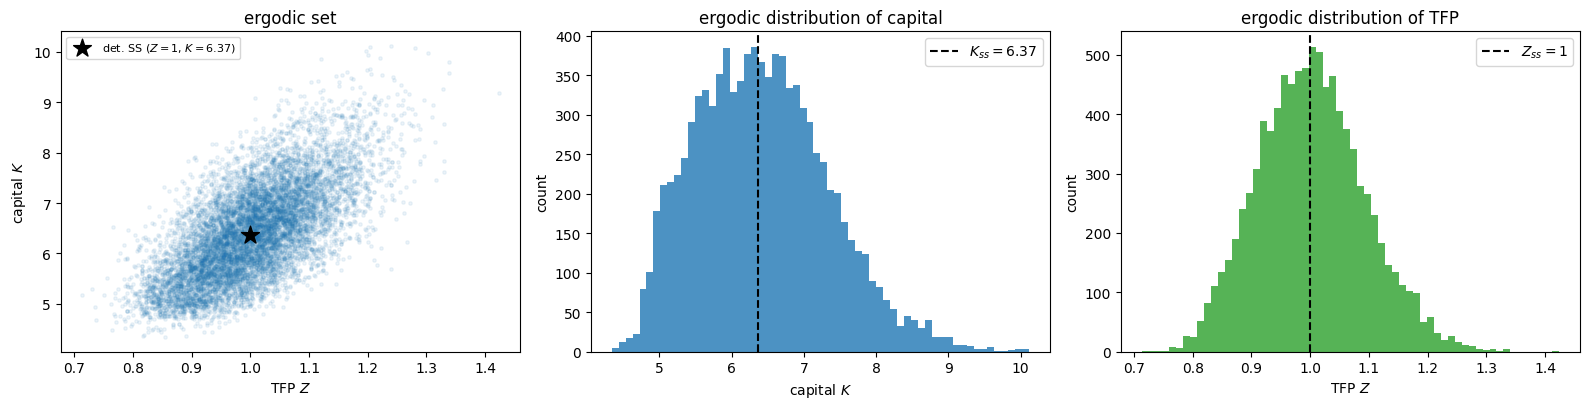

K  mean / std = 6.422 / 0.917
Z  mean / std = 1.002 / 0.091


In [9]:
eval_result = euler_equation_errors(policy_net, MODEL, n_periods=10_000, seed=123)
states_path = np.asarray(eval_result["states"])
resid_path = np.asarray(eval_result["residuals"])

K_path = states_path[:, 0]
Z_path = np.exp(states_path[:, 1])
K_ss = float(ss_state[0])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# Ergodic cloud (capital vs TFP), as in the reference notebook.
axes[0].scatter(Z_path, K_path, s=6, alpha=0.08, color="C0")
axes[0].scatter([1.0], [K_ss], color="k", marker="*", s=180, zorder=5,
                label=f"det. SS ($Z=1$, $K={K_ss:.2f}$)")
axes[0].set_xlabel("TFP $Z$")
axes[0].set_ylabel("capital $K$")
axes[0].set_title("ergodic set")
axes[0].legend(fontsize=8)

axes[1].hist(K_path, bins=60, color="C0", alpha=0.8)
axes[1].axvline(K_ss, color="k", ls="--", label=f"$K_{{ss}} = {K_ss:.2f}$")
axes[1].set_xlabel("capital $K$")
axes[1].set_ylabel("count")
axes[1].set_title("ergodic distribution of capital")
axes[1].legend()

axes[2].hist(Z_path, bins=60, color="C2", alpha=0.8)
axes[2].axvline(1.0, color="k", ls="--", label="$Z_{ss} = 1$")
axes[2].set_xlabel("TFP $Z$")
axes[2].set_ylabel("count")
axes[2].set_title("ergodic distribution of TFP")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"K  mean / std = {K_path.mean():.3f} / {K_path.std():.3f}")
print(f"Z  mean / std = {Z_path.mean():.3f} / {Z_path.std():.3f}")

## 8. Euler accuracy diagnostics

The Azinovic et al. (2022) DEQN accuracy report: percentile table of $\log_{10}|\mathrm{resid}|$ along the simulated ergodic path, both in raw units (what the loss sees) and in the dimensionless $|\mathrm{resid}/u'(C)|$ units used across the literature for cross-study comparison.

The dimensionless metric answers "how far off is the Euler FOC, expressed as a fraction of marginal utility" — the interpretation is that a value of $-3$ means the Euler condition holds to 0.1% accuracy, $-4$ to 0.01%, etc. Grade thresholds (Good / Acceptable / Poor) follow the Den Haan–Marcet convention.

> **Calibrating against the reference.** Simon's TF/Keras notebook (run freshly with identical calibration and the same phase-1 recipe) reaches mean $\log_{10}|\mathrm{errREE}| \approx -3.14$ on this model. Our single-phase run lands around $-2.3$, a real ~0.85-decade accuracy gap that isn't explained by LR schedule, MC vs GH quadrature, or residual-form rescaling. Under investigation; leading candidates are input feature scale (we feed log-TFP where Simon feeds level-TFP) and the loss form's per-state weighting. The policy is qualitatively correct and economically usable — it just doesn't match the reference's tightness.

In [10]:
import jax

from deqn_jax.evaluate import print_euler_errors
from deqn_jax.models.brock_mirman.equations import definitions as bm_defs

# Dimensionless residual = raw / u'(C) at the sampled state.
# Reconstruct u'(C) by re-running definitions on the saved states + current policy.
states_jnp = jnp.asarray(states_path)
policies_jnp = jax.vmap(policy_net)(states_jnp)
defs_path = bm_defs(states_jnp, policies_jnp, MODEL.constants)
u_c_path = np.asarray(defs_path["u_c"])  # [T]
dimless_resid = resid_path[:, 0] / u_c_path  # [T]

# 1) Raw-unit table via the framework helper.
print_euler_errors(eval_result, label="raw residual units")


# 2) Dimensionless table, same format.
def _pct_row(name, vals):
    lg = np.log10(np.maximum(np.abs(vals), 1e-20))
    p = np.percentile(lg, [50, 95, 99, 99.9])
    grade = (
        "Very good"
        if lg.mean() < -4
        else "Good"
        if lg.mean() < -3
        else "Acceptable"
        if lg.mean() < -2
        else "POOR"
    )
    print(
        f"{name:>30s}  {lg.mean():>7.2f}  {p[0]:>7.2f}  {p[1]:>7.2f}  "
        f"{p[2]:>7.2f}  {p[3]:>7.2f}  {lg.max():>7.2f}  {grade:>12s}"
    )


print("\nEuler Equation Errors (log10) — dimensionless |resid/u_c|")
print("=" * 100)
print(
    f"{'Equation':>30s}  {'Mean':>7s}  {'p50':>7s}  {'p95':>7s}  {'p99':>7s}  {'p99.9':>7s}  {'Max':>7s}  {'Grade':>12s}"
)
print("-" * 100)
_pct_row("euler", dimless_resid)
print()


Euler Equation Errors (log10) — raw residual units
                      Equation     Mean      p50      p95      p99    p99.9      Max         Grade
----------------------------------------------------------------------------------------------------
                         euler    -2.40    -2.33    -1.73    -1.57    -1.44    -1.32    Acceptable
----------------------------------------------------------------------------------------------------
                       OVERALL    -2.40    -2.33    -1.73    -1.57    -1.44    -1.32

  Mean log10 error: -2.40 → 3.9e-03 (<1% Acceptable)
  Max  log10 error: -1.32 → 4.8e-02 (<10% Acceptable)

Euler Equation Errors (log10) — dimensionless |resid/u_c|
                      Equation     Mean      p50      p95      p99    p99.9      Max         Grade
----------------------------------------------------------------------------------------------------
                         euler    -2.29    -2.20    -1.63    -1.49    -1.35    -1.20    Acceptab

### Errors conditional on state

Ergodic errors can hide bad pockets — residuals can be uniformly small except in an edge region. Report the dimensionless residual by $K$-quartile of the simulated path so any sub-region weakness shows up.

In [11]:
k_quartiles = np.quantile(K_path, [0.25, 0.50, 0.75])
bin_labels = [
    f"K ≤ {k_quartiles[0]:.2f}",
    f"{k_quartiles[0]:.2f} < K ≤ {k_quartiles[1]:.2f}",
    f"{k_quartiles[1]:.2f} < K ≤ {k_quartiles[2]:.2f}",
    f"K > {k_quartiles[2]:.2f}",
]
bin_idx = np.digitize(K_path, k_quartiles)  # 0..3

print(f"{'K bin':>36s}  {'n':>6s}  {'mean':>7s}  {'p50':>7s}  {'p95':>7s}  {'p99':>7s}")
print("-" * 82)
for b, label in enumerate(bin_labels):
    vals = dimless_resid[bin_idx == b]
    lg = np.log10(np.maximum(np.abs(vals), 1e-20))
    p = np.percentile(lg, [50, 95, 99])
    print(
        f"{label:>36s}  {len(vals):>6d}  {lg.mean():>7.2f}  {p[0]:>7.2f}  {p[1]:>7.2f}  {p[2]:>7.2f}"
    )

                               K bin       n     mean      p50      p95      p99
----------------------------------------------------------------------------------
                            K ≤ 5.72    2375    -2.17    -2.08    -1.57    -1.44
                     5.72 < K ≤ 6.37    2375    -2.31    -2.24    -1.62    -1.48
                     6.37 < K ≤ 7.02    2375    -2.37    -2.28    -1.73    -1.58
                            K > 7.02    2375    -2.30    -2.20    -1.67    -1.54


### Distribution of errors

Histogram of the dimensionless $\log_{10}|\mathrm{resid}/u'(C)|$ along the ergodic
path, with the **median, p90, and p99** marked (the literature-standard quantile
certificate, not a mean — the distribution is long-tailed so a mean would be
misleading). The table above is the numeric summary; this shows distribution shape.

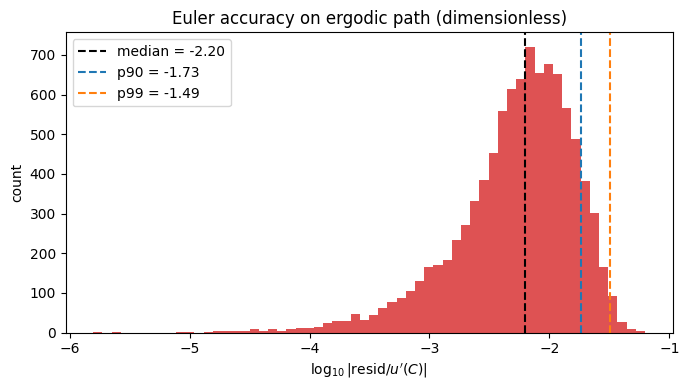

In [12]:
log_abs_resid = np.log10(np.maximum(np.abs(dimless_resid), 1e-20))
q50, q90, q99 = np.percentile(log_abs_resid, [50, 90, 99])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_abs_resid, bins=60, color="C3", alpha=0.8)
ax.axvline(q50, color="k", ls="--", lw=1.5, label=f"median = {q50:.2f}")
ax.axvline(q90, color="C0", ls="--", lw=1.5, label=f"p90 = {q90:.2f}")
ax.axvline(q99, color="C1", ls="--", lw=1.5, label=f"p99 = {q99:.2f}")
ax.set_xlabel(r"$\log_{10}|\mathrm{resid}/u'(C)|$")
ax.set_ylabel("count")
ax.set_title("Euler accuracy on ergodic path (dimensionless)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Impulse response to a TFP shock

One-off +1σ innovation to $\varepsilon_z$ at period 1, then deterministic continuation. The framework's `run_irf` handles shock injection and records every state, policy, definition, and equation residual along the path. `plot_irf_grid` is a generic multi-panel plotter over the returned dict.

In [ ]:
irf_results = run_irf(policy_net, MODEL, shock_name="eps_z", shock_size=1.0, horizon=40)

variables_to_plot = ["k", "Z", "c", "y", "sav_rate"]
fig = plot_irf_grid(
    {"eps_z": irf_results},
    variables=variables_to_plot,
    title="IRF to +1σ TFP innovation",
)
plt.show()

## Summary

- Same economic model as the reference notebook; zero lines of training-loop, loss, or optimizer code in the notebook itself.
- Diagnostics are composable: `history` → loss plots; trained `policy_net` + `MODEL` → policy / Euler-error scatters, ergodic stats, IRFs.
- The two primitives that make this work are the `ModelSpec` data contract and the `train_from_config` entry point. Every ported model will follow this same notebook template, swapping only the model registration string and the plots that are specific to its economics.

Template for per-model notebooks:
1. Preamble with economics and FOCs
2. `ModelSpec` inspection
3. `train_from_config(cfg)`
4. Loss curve (`plot_loss_curve`)
5. Policy & consumption scatters (model-specific)
6. Relative Euler error (signed errREE) + LHS-vs-RHS check
7. Ergodic simulation (cloud + marginals)
8. Quantile accuracy certificate + `log₁₀|resid|` distribution on ergodic path
9. IRF via `run_irf` + `plot_irf_grid`